In [ ]:
# Downloaded the cutomer store csv
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datascientistanna/customers-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/datascientistanna/customers-dataset/versions/1


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/datascientistanna/customers-dataset/versions/1/Customers.csv"
)

df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [ ]:
# gives last rows
df.tail()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2
1999,2000,Male,90,110610,52,Entertainment,5,2


In [ ]:
df.shape # method to check data rows and columns-rows:2000, columns:8

(2000, 8)

In [ ]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nStatistics:")
display(df.describe())


Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 n

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [ ]:
# Catagorical view
print(df["Gender"].value_counts())

Gender
Female    1186
Male       814
Name: count, dtype: int64


In [ ]:
# Percentage
print(
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Gender
Female    59.3
Male      40.7
Name: proportion, dtype: float64


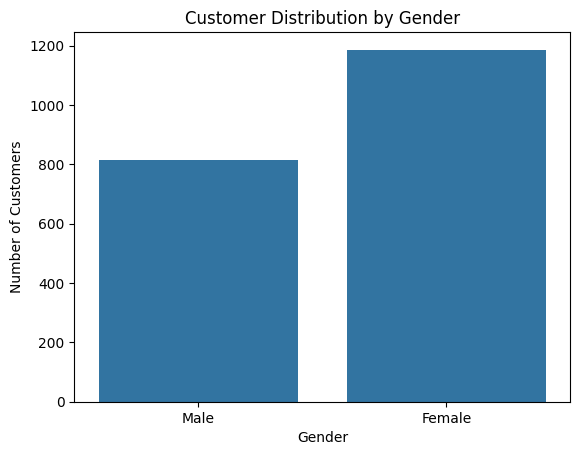

In [ ]:
# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Neumerical data
print(df["Age"].describe())

count    2000.000000
mean       48.960000
std        28.429747
min         0.000000
25%        25.000000
50%        48.000000
75%        73.000000
max        99.000000
Name: Age, dtype: float64


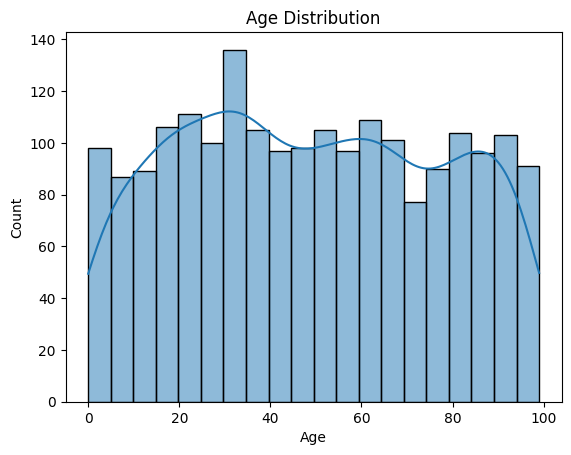

In [ ]:
# Histogram
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

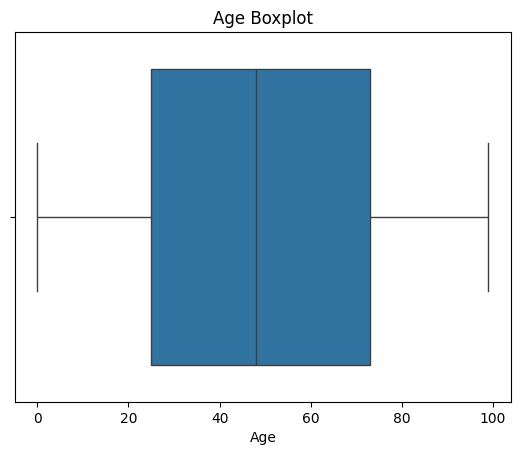

In [ ]:
# Box plot
sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Age Boxplot")
plt.show()

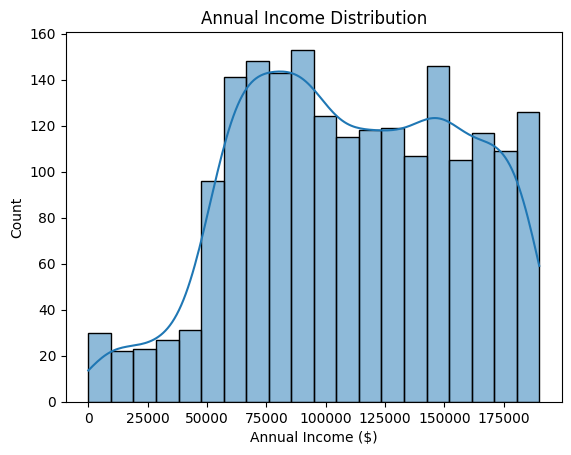

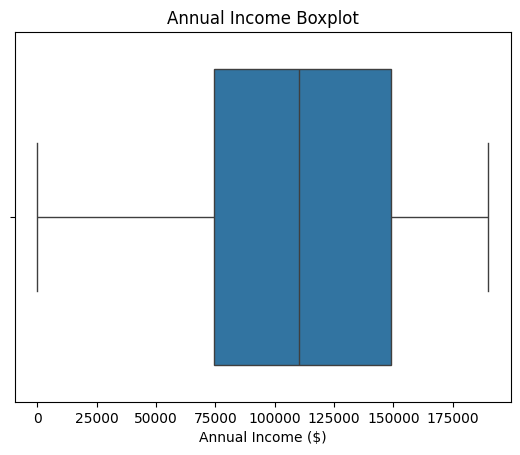

In [ ]:
# Annual Income analysis
sns.histplot(
    data=df,
    x="Annual Income ($)",
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")
plt.show()

# Box plot
sns.boxplot(
    data=df,
    x="Annual Income ($)"
)

plt.title("Annual Income Boxplot")
plt.show()

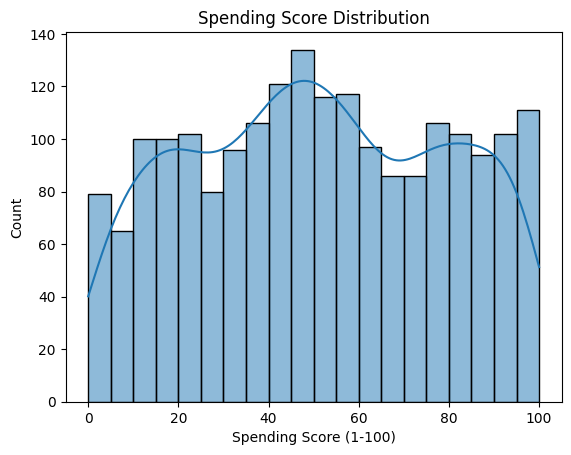

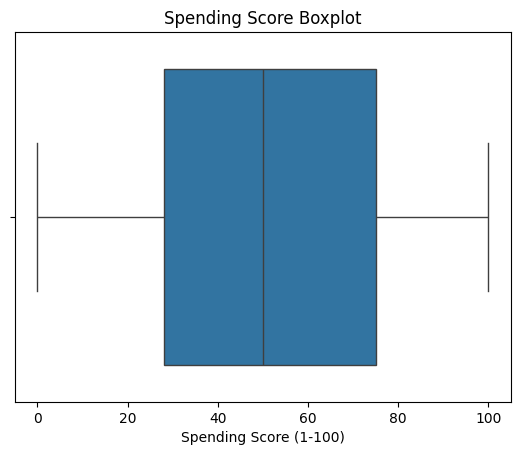

In [ ]:
# Spending Score analysis
sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")
plt.show()

# Boxplot
sns.boxplot(
    data=df,
    x="Spending Score (1-100)"
)

plt.title("Spending Score Boxplot")
plt.show()

In [ ]:
# Detect outliers using IQR
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Outliers:", len(outliers))

    return outliers

print("Age IQR\n")
age_outliers = detect_outliers_iqr(df, "Age")
print("\nIncome IQR\n")
income_outliers = detect_outliers_iqr(
    df,
    "Annual Income ($)"
)

Age IQR

Column: Age
Q1: 25.0
Q3: 73.0
IQR: 48.0
Lower bound: -47.0
Upper bound: 145.0
Outliers: 0

Income IQR

Column: Annual Income ($)
Q1: 74572.0
Q3: 149092.75
IQR: 74520.75
Lower bound: -37209.125
Upper bound: 260873.875
Outliers: 0


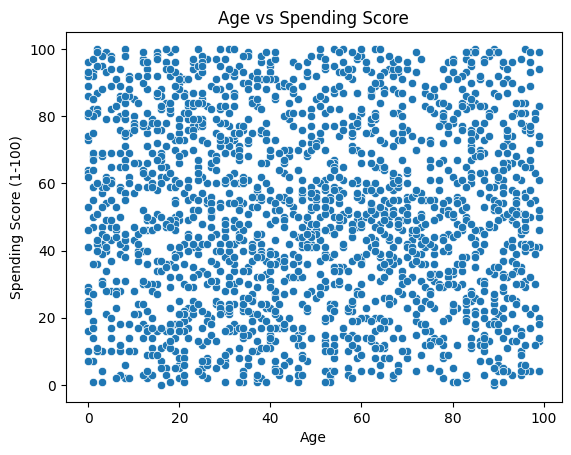

In [ ]:
# Bivariate EDA
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)"
)

plt.title("Age vs Spending Score")
plt.show()

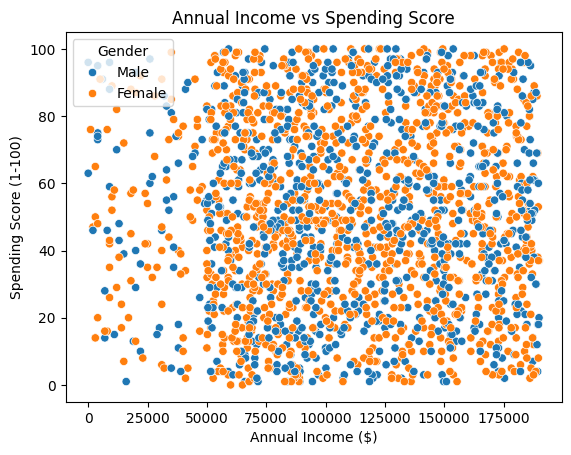

In [ ]:
# Income vs Spending
sns.scatterplot(
    data=df,
    x="Annual Income ($)",
    y="Spending Score (1-100)",
    hue="Gender"
)

plt.title("Annual Income vs Spending Score")
plt.show()

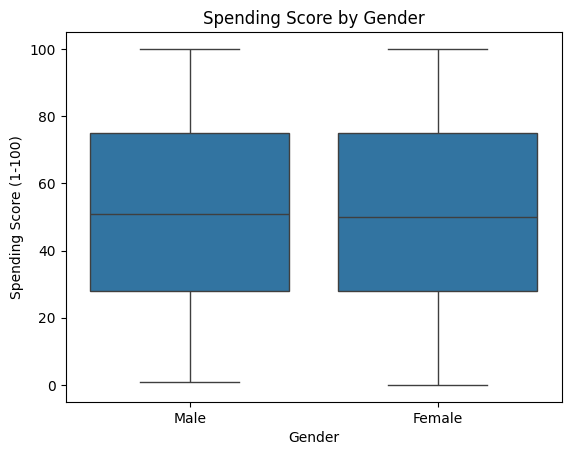

,count,mean,median,std
Gender,,,,
Female,1186,50.974705,50.0,28.032580
Male,814,50.944717,51.0,27.808573


In [ ]:
# Gender vs Spending
sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)"
)

plt.title("Spending Score by Gender")
plt.show()
# Neumerically
df.groupby("Gender")[
    "Spending Score (1-100)"
].agg(["count", "mean", "median", "std"])

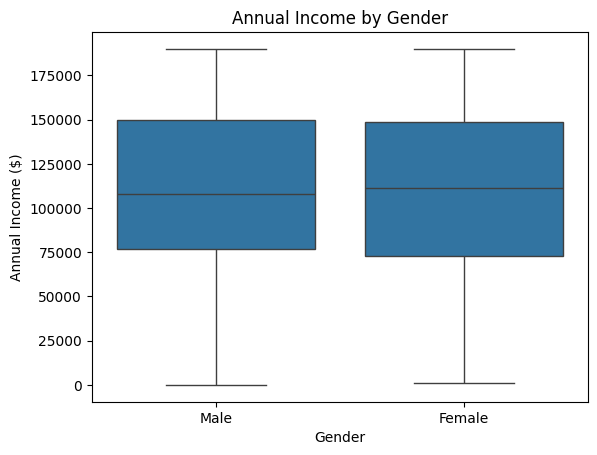

In [ ]:
# Gender vs Income
sns.boxplot(
    data=df,
    x="Gender",
    y="Annual Income ($)"
)

plt.title("Annual Income by Gender")
plt.show()

                        CustomerID       Age  Annual Income ($)  \
CustomerID                1.000000  0.070700           0.328400   
Age                       0.070700  1.000000           0.021378   
Annual Income ($)         0.328400  0.021378           1.000000   
Spending Score (1-100)    0.018936 -0.041798           0.023299   
Work Experience           0.091574 -0.014319           0.089136   
Family Size               0.159655  0.038254           0.093005   

                        Spending Score (1-100)  Work Experience  Family Size  
CustomerID                            0.018936         0.091574     0.159655  
Age                                  -0.041798        -0.014319     0.038254  
Annual Income ($)                     0.023299         0.089136     0.093005  
Spending Score (1-100)                1.000000        -0.028948     0.002232  
Work Experience                      -0.028948         1.000000     0.011873  
Family Size                           0.002232         0

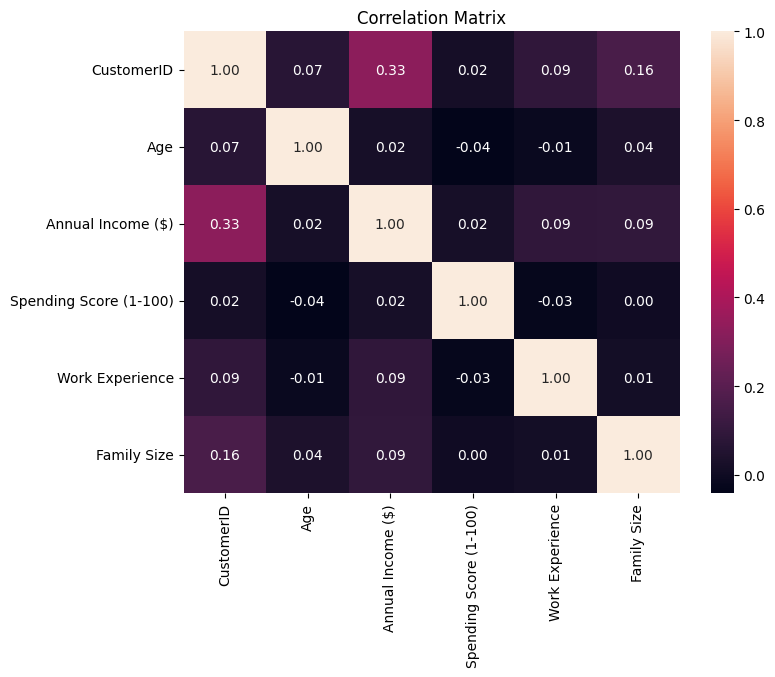

In [ ]:
# Correlation analysis
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

print(correlation)

# Visually
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

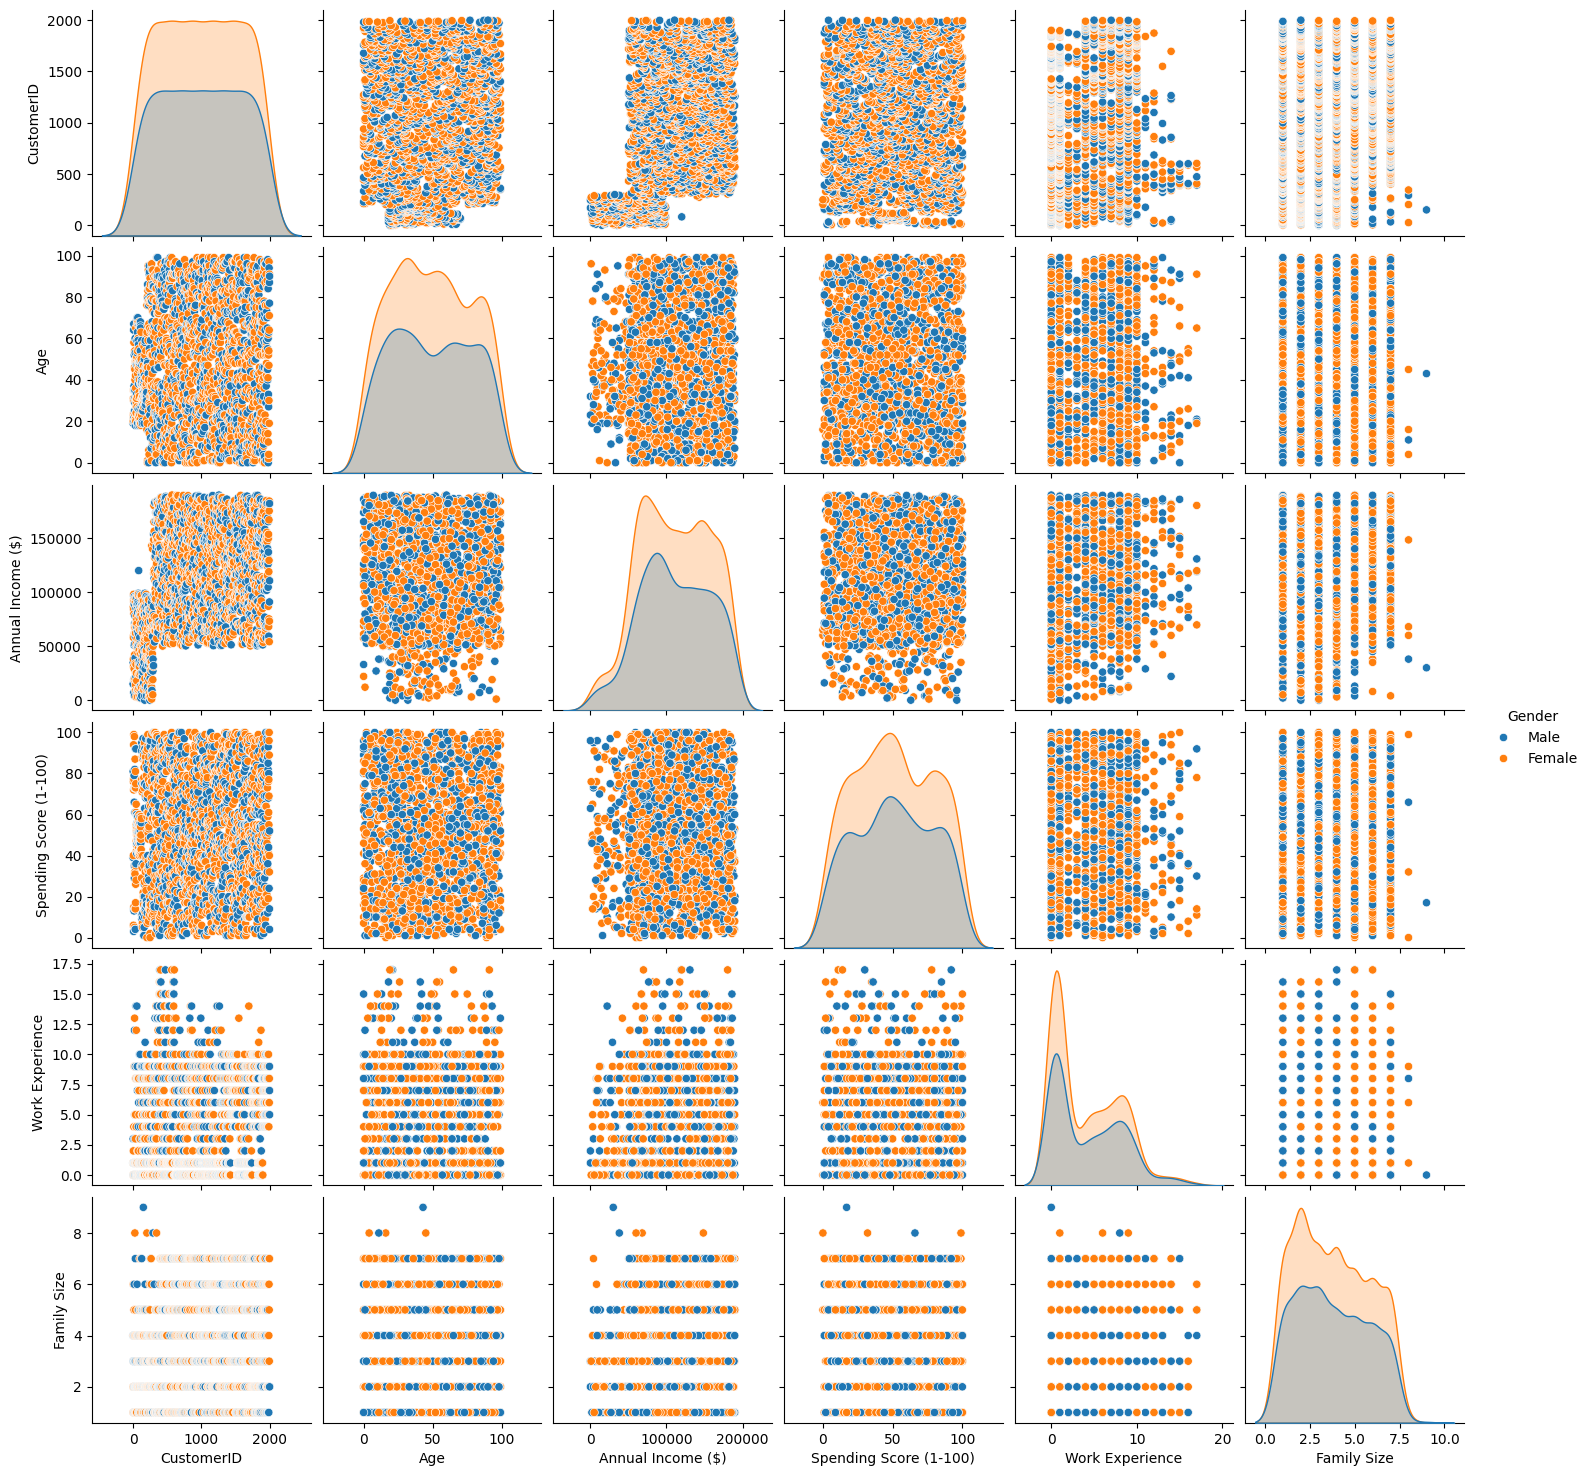

In [ ]:
# Pairplot
sns.pairplot(
    df,
    hue="Gender"
)

plt.show()

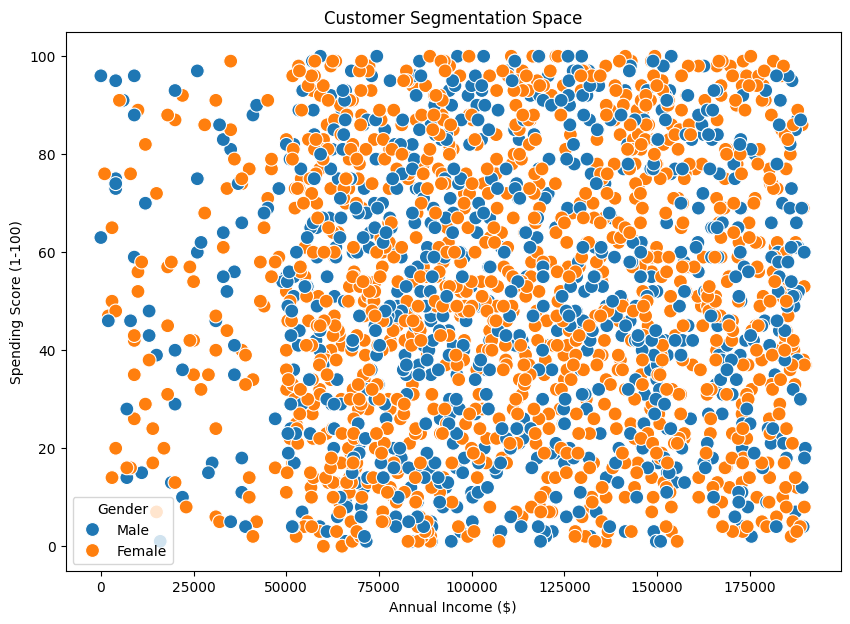

In [ ]:
# Customer segmentation visualization
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income ($)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=100
)

plt.title("Customer Segmentation Space")
plt.show()

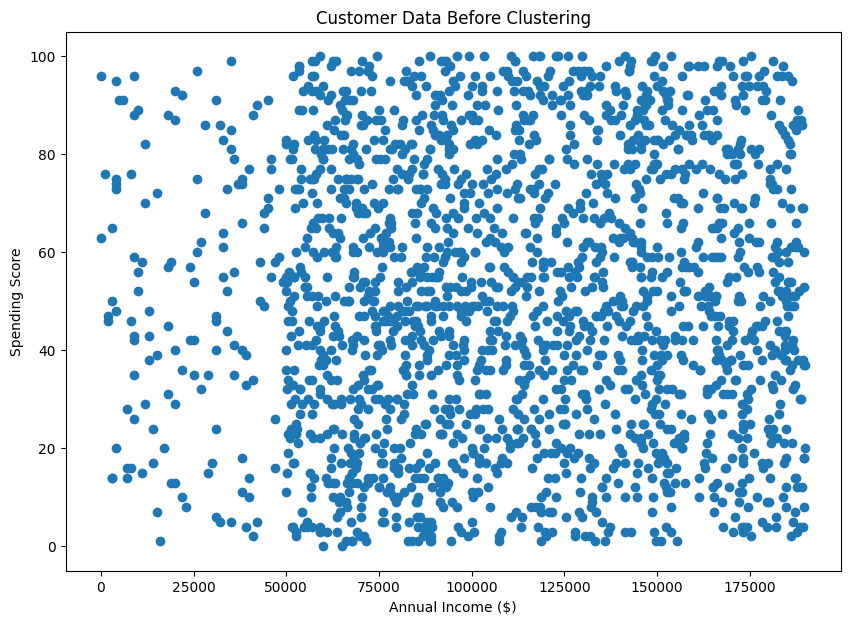

In [ ]:
# Prepare for K-Means
X = df[
    [
        "Annual Income ($)",
        "Spending Score (1-100)"
    ]
]

# Visually
plt.figure(figsize=(10, 7))

plt.scatter(
    X["Annual Income ($)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score")
plt.title("Customer Data Before Clustering")

plt.show()

In [ ]:
# EDA with standardized data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

# Compare
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-2.09350095 -0.42833854]
 [-1.65613312  1.07554599]
 [-0.54084515 -1.6099621 ]
 [-1.13129172  0.93231889]
 [-1.59052794 -0.39253176]]
[[-2.09350095 -0.42833854]
 [-1.65613312  1.07554599]
 [-0.54084515 -1.6099621 ]
 [-1.13129172  0.93231889]
 [-1.59052794 -0.39253176]]


Explained variance: [0.5116497 0.4883503]


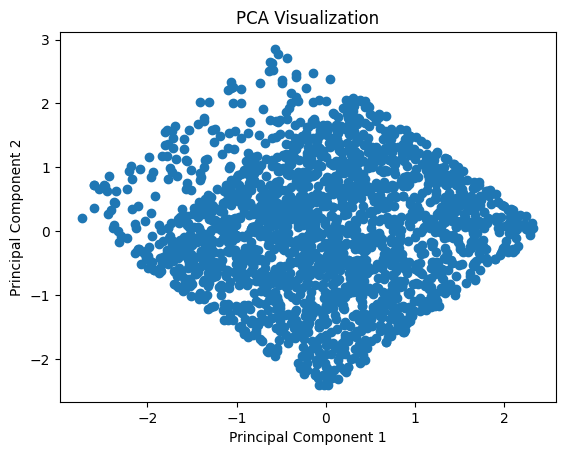

In [ ]:
# PCA EDA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

# Visually
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.show()

In [ ]:
!pip install ydata-profiling
# Automatically generate an EDA report
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="E-Commerce Customer EDA Report",
    explorative=True
)

profile.to_notebook_iframe()

# Save to html
profile.to_file(
    "ecommerce_eda_report.html"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.7 MB/s eta 0:00:00


/tmp/ipykernel_5872/1328642422.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 52.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

DATASET SHAPE
(2000, 8)

COLUMNS
['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size']

DATA TYPES
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience  

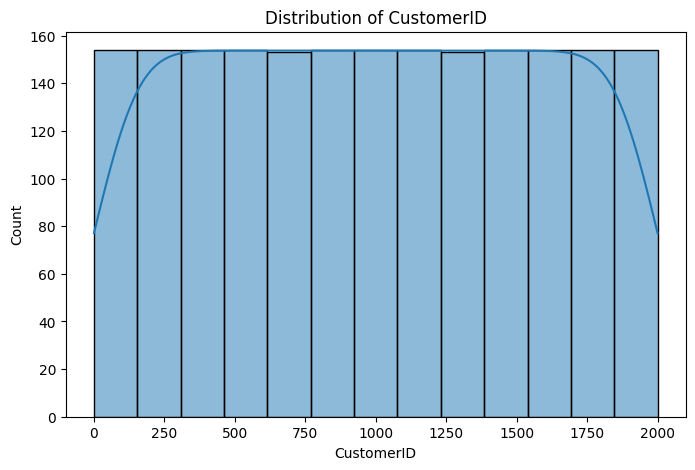

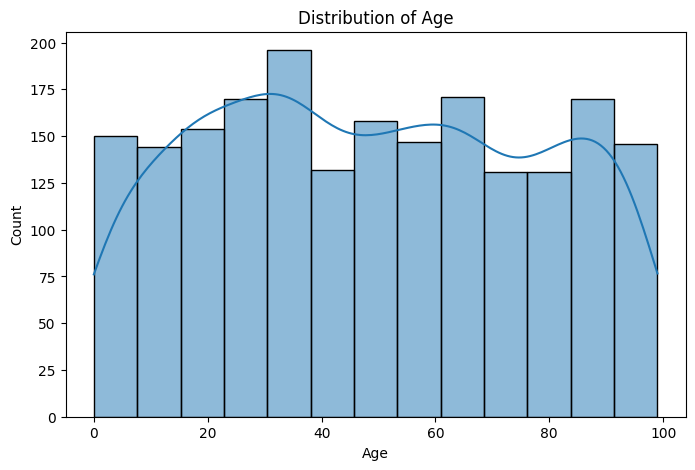

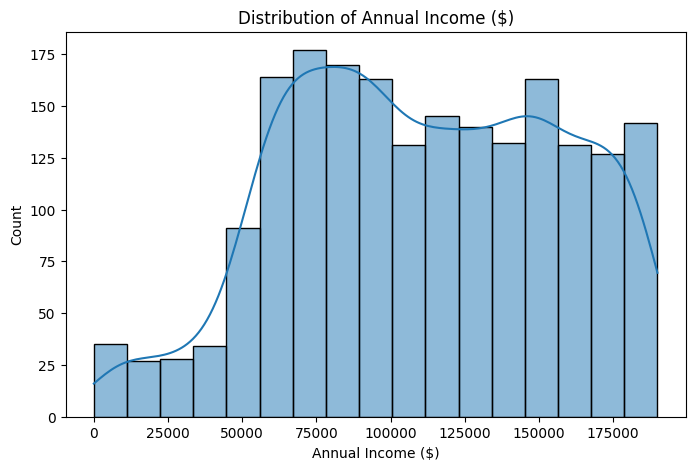

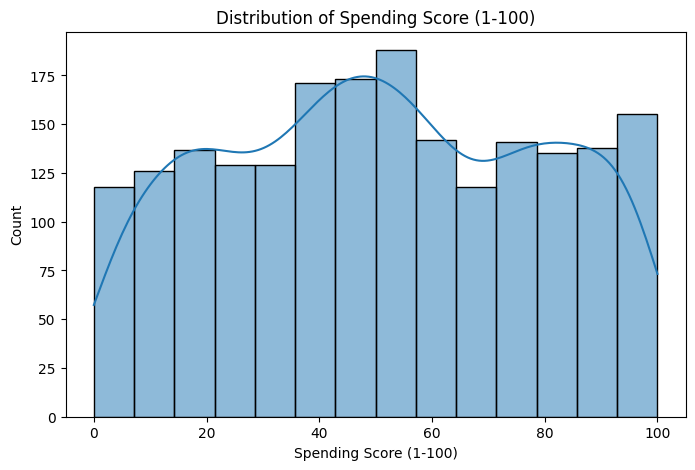

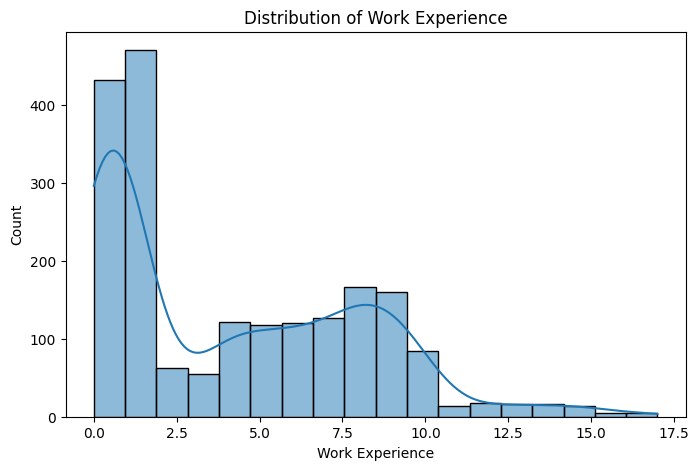

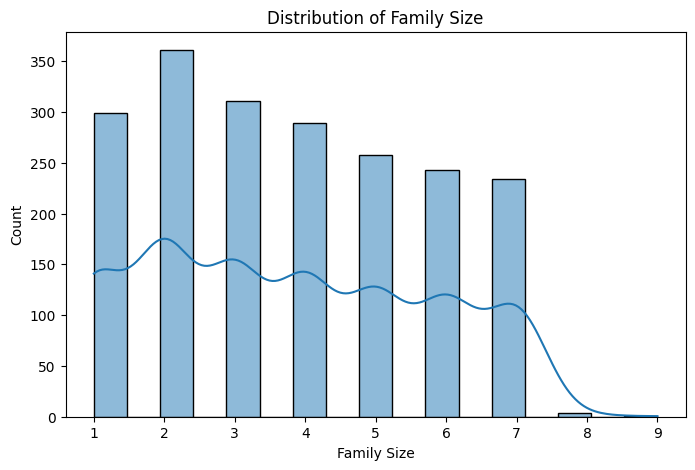

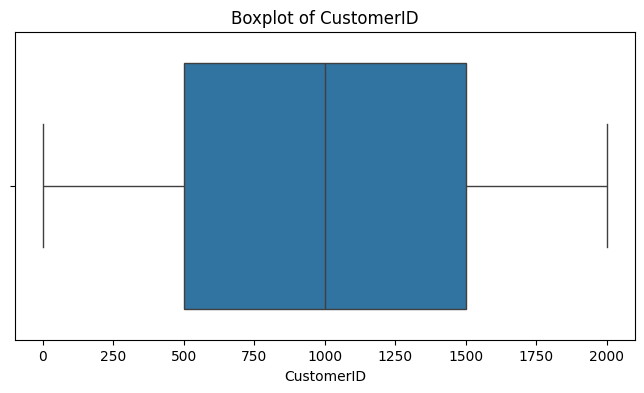

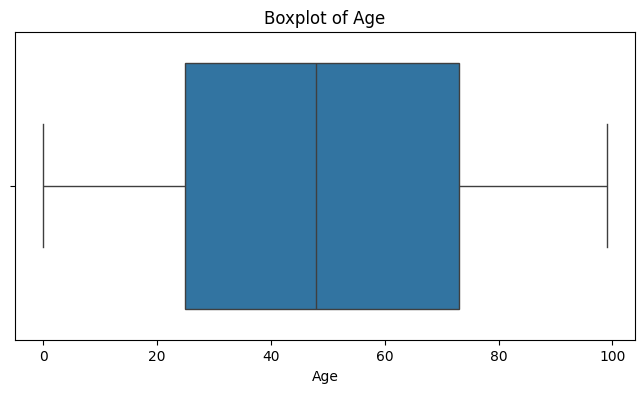

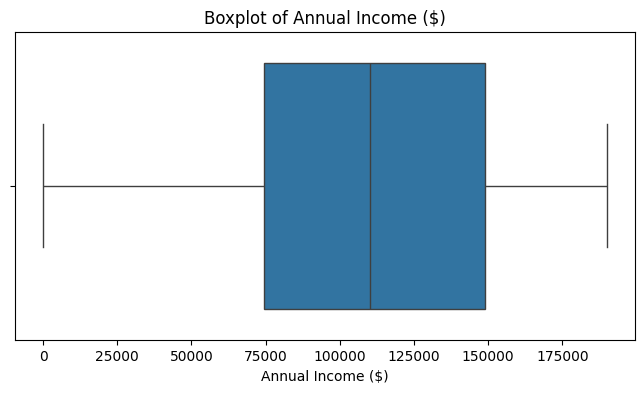

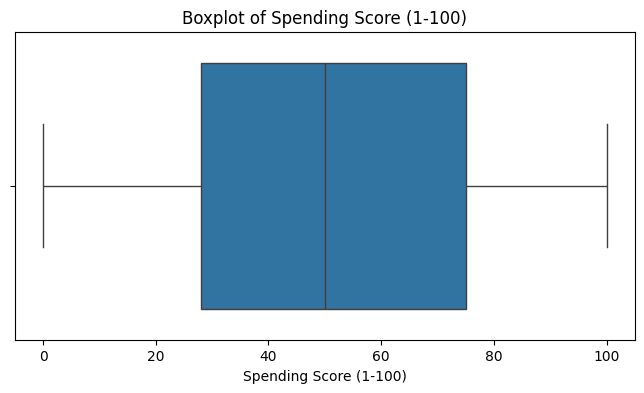

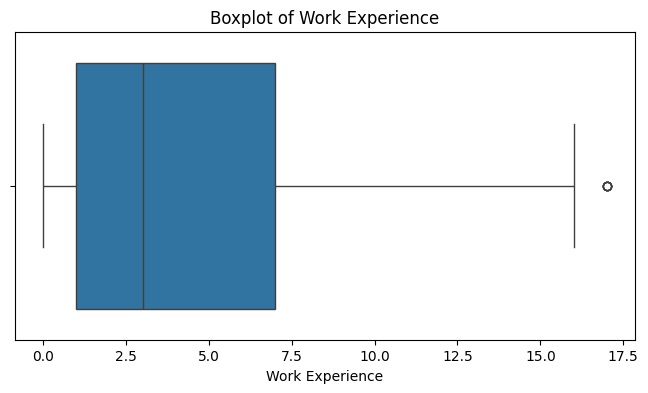

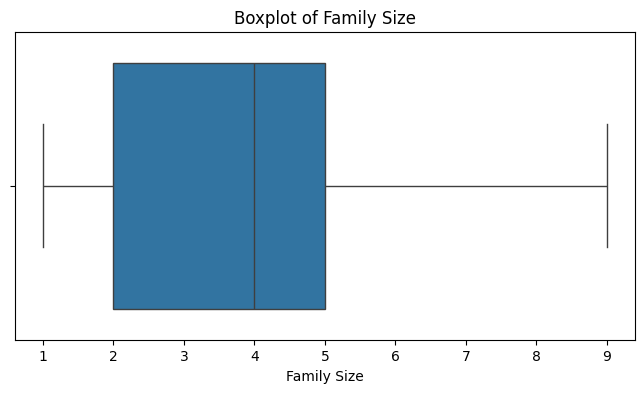

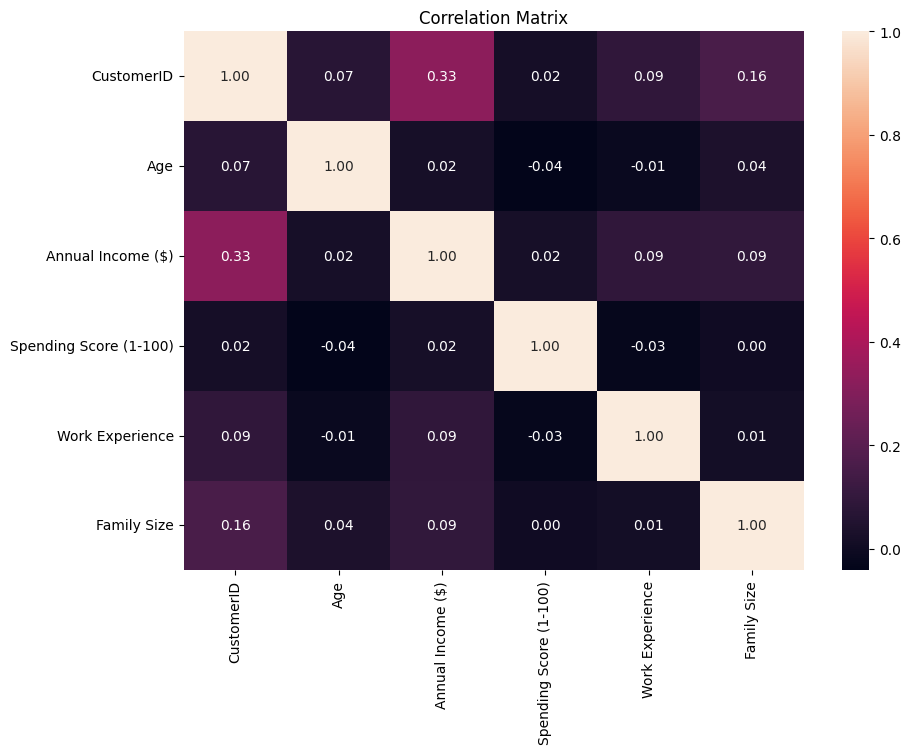

In [ ]:
# Build an EDA pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv("/root/.cache/kagglehub/datasets/datascientistanna/customers-dataset/versions/1/Customers.csv")


# =========================
# 2. BASIC INFORMATION
# =========================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(df.shape)


print("\nCOLUMNS")
print(df.columns.tolist())


print("\nDATA TYPES")
print(df.dtypes)


print("\nINFO")
df.info()


# =========================
# 3. DUPLICATES
# =========================

print("\nDUPLICATES")
print(df.duplicated().sum())


# =========================
# 4. MISSING VALUES
# =========================

print("\nMISSING VALUES")

missing = pd.DataFrame({
    "count": df.isnull().sum(),
    "percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

print(
    missing.sort_values(
        "percentage",
        ascending=False
    )
)


# =========================
# 5. STATISTICS
# =========================

print("\nNUMERICAL STATISTICS")

print(
    df.describe()
)


# =========================
# 6. CATEGORICAL STATISTICS
# =========================

print("\nCATEGORICAL STATISTICS")

print(
    df.describe(include="object")
)


# =========================
# 7. UNIQUE VALUES
# =========================

print("\nUNIQUE VALUES")

for col in df.columns:
    print(
        col,
        "→",
        df[col].nunique()
    )


# =========================
# 8. NUMERICAL FEATURES
# =========================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

print("\nNUMERICAL FEATURES:")
print(list(numeric_columns))


# =========================
# 9. CATEGORICAL FEATURES
# =========================

categorical_columns = df.select_dtypes(
    include="object"
).columns

print("\nCATEGORICAL FEATURES:")
print(list(categorical_columns))


# =========================
# 10. DISTRIBUTIONS
# =========================

for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.show()


# =========================
# 11. BOXPLOTS
# =========================

for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Boxplot of {column}"
    )

    plt.show()


# =========================
# 12. CORRELATION
# =========================

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()